# Exploratory Data Analysis - Dynamic Pricing AI

This notebook explores the generated market data to understand patterns in demand, pricing, and competition.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## Load Data

In [2]:
df = pd.read_csv("../data/processed/super_model_data_clean.csv")
df.head()

,price,demand,competitor_price,inventory,day_of_week,price_gap,price_ratio,inventory_pressure,is_weekend,dow_sin,dow_cos,demand_lag_1,demand_lag_7,demand_roll_mean_7
0,736.7,14.0,770.37,149,1,-33.67,0.956294,0.029640,0,0.781831,0.62349,4.0,4.0,14.000000
1,715.5,6.0,603.88,138,1,111.62,1.184838,0.027452,0,0.781831,0.62349,14.0,4.0,10.000000
2,715.5,18.0,796.04,148,1,-80.54,0.898824,0.029441,0,0.781831,0.62349,6.0,4.0,12.666667
3,132.5,5.0,93.72,754,1,38.78,1.413786,0.149990,0,0.781831,0.62349,79.0,4.0,24.400000
4,174.9,9.0,140.74,214,1,34.16,1.242717,0.042570,0,0.781831,0.62349,5.0,4.0,21.833333


## Summary Statistics

In [3]:
df.describe()

,price,demand,competitor_price,inventory,day_of_week,price_gap,price_ratio,inventory_pressure,is_weekend,dow_sin,dow_cos,demand_lag_1,demand_lag_7,demand_roll_mean_7
count,1.027351e+06,1.027351e+06,1.027351e+06,1.027351e+06,1.027351e+06,1.027351e+06,1.027351e+06,1.027351e+06,1.027351e+06,1.027351e+06,1.027351e+06,1.027351e+06,1.027351e+06,1.027351e+06
mean,2.947456e+02,8.739355e+00,2.933210e+02,1.845316e+02,2.516041e+00,1.424585e+00,1.028342e+00,3.670811e-02,1.457486e-01,2.104782e-01,3.581617e-02,9.979304e+00,1.007806e+01,9.855044e+00
std,2.399906e+02,1.250882e+01,2.436712e+02,1.444718e+02,1.907273e+00,5.532587e+01,1.626054e-01,2.873917e-02,3.528542e-01,6.181137e-01,7.565398e-01,1.909603e+01,1.928067e+01,1.182351e+01
min,1.810000e+01,0.000000e+00,1.249000e+01,0.000000e+00,0.000000e+00,-4.455300e+02,5.758088e-01,0.000000e+00,0.000000e+00,-9.749279e-01,-9.009689e-01,0.000000e+00,0.000000e+00,1.000000e+00
25%,1.325000e+02,1.000000e+00,1.207100e+02,1.080000e+02,1.000000e+00,-1.838500e+01,9.156351e-01,2.148399e-02,0.000000e+00,-4.338837e-01,-9.009689e-01,1.000000e+00,1.000000e+00,2.428571e+00
50%,2.204800e+02,3.000000e+00,2.107700e+02,1.300000e+02,2.000000e+00,9.800000e-01,1.006567e+00,2.586035e-02,0.000000e+00,4.338837e-01,-2.225209e-01,3.000000e+00,3.000000e+00,5.714286e+00
75%,3.975000e+02,1.000000e+01,3.937200e+02,1.930000e+02,4.000000e+00,1.996000e+01,1.115414e+00,3.839268e-02,0.000000e+00,7.818315e-01,6.234898e-01,1.000000e+01,1.000000e+01,1.228571e+01
max,1.244440e+03,7.400000e+01,1.274130e+03,1.073000e+03,6.000000e+00,7.223100e+02,3.835022e+00,2.134474e-01,1.000000e+00,9.749279e-01,1.000000e+00,7.410000e+02,7.410000e+02,1.778571e+02


## Visualize Distribution of Demand

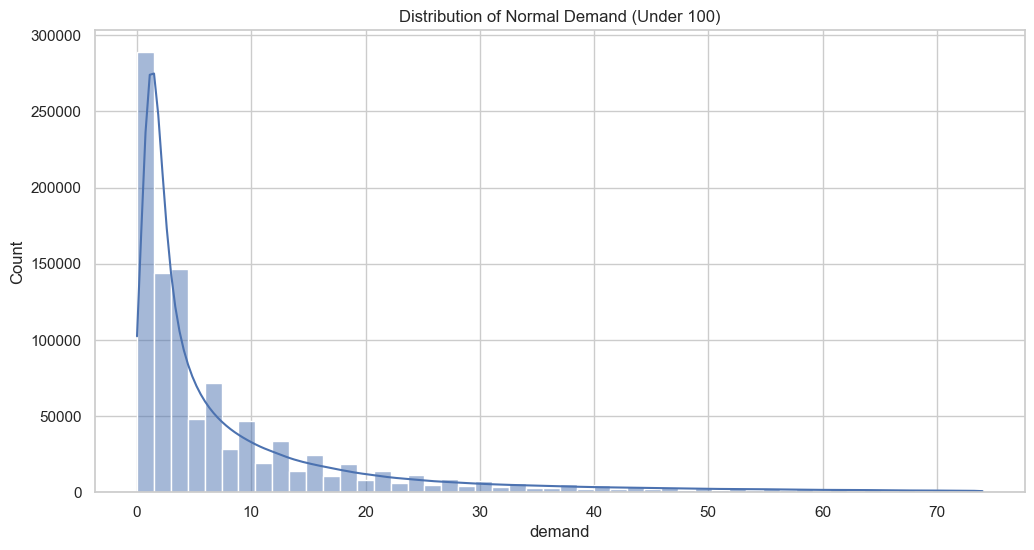

In [4]:
sns.histplot(df[df['demand'] < 100]['demand'], kde=True, bins=50)
plt.title('Distribution of Normal Demand (Under 100)')
plt.show()

## Demand Curve Visualization
a trend line helps interpret the demand curve.

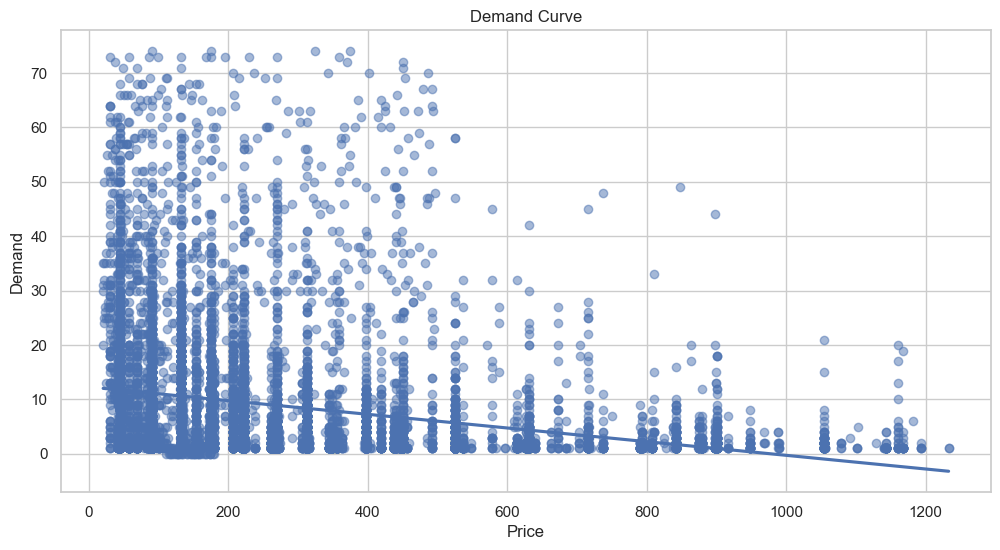

In [5]:
sns.regplot(x="price", y="demand", data=df.sample(min(10000, len(df))), ci=None, scatter_kws={"alpha":0.5})
plt.title("Demand Curve")
plt.xlabel("Price")
plt.ylabel("Demand")
plt.show()

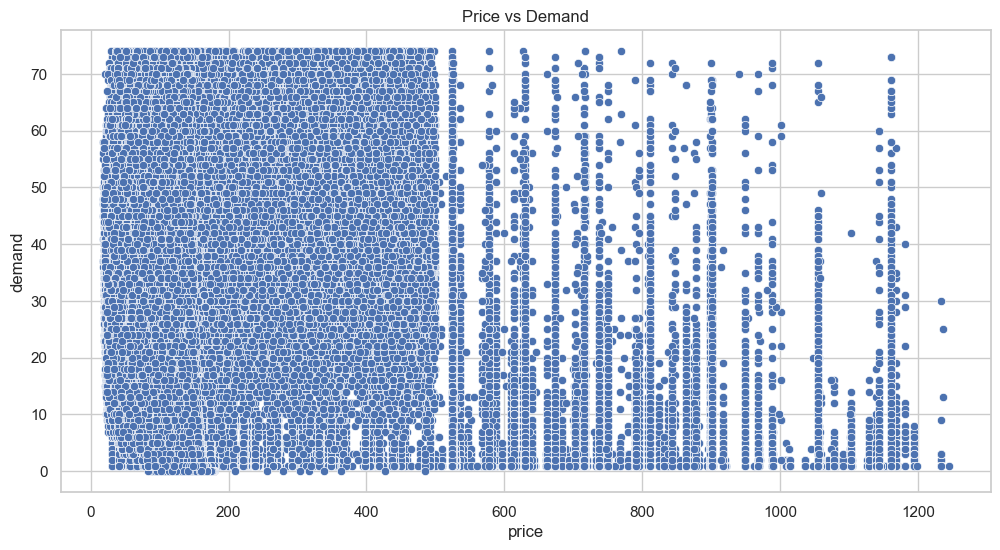

In [6]:
sns.scatterplot(x='price', y='demand', data=df)
plt.title('Price vs Demand')
plt.show()

## Correlation Analysis

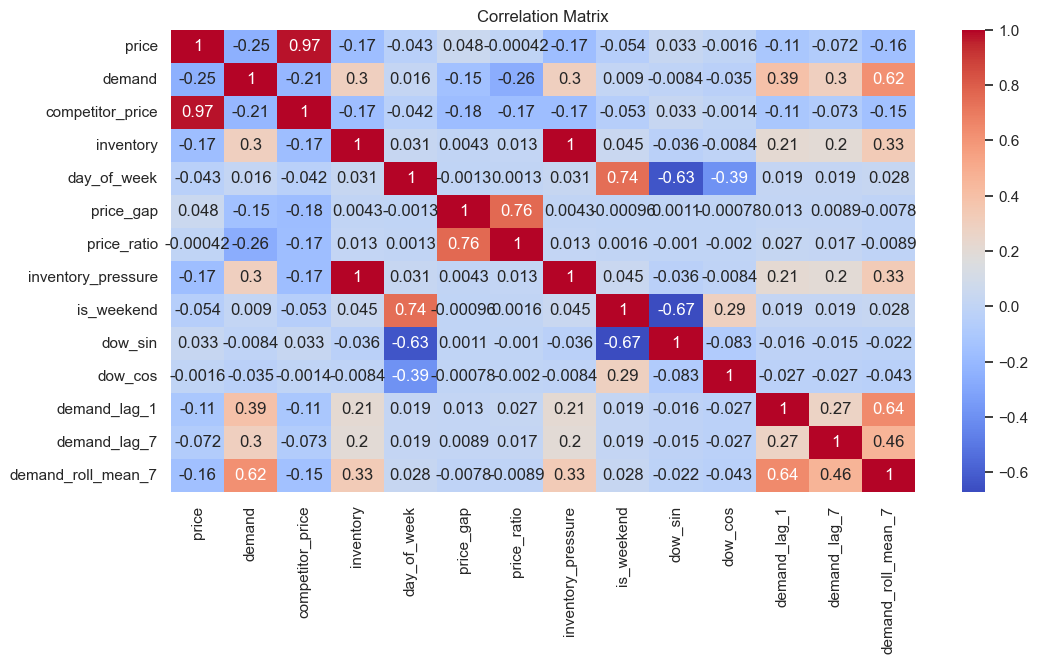

In [7]:
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title('Correlation Matrix')
plt.show()

## Price vs Demand

c:\Dynamic_pricing_AI\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


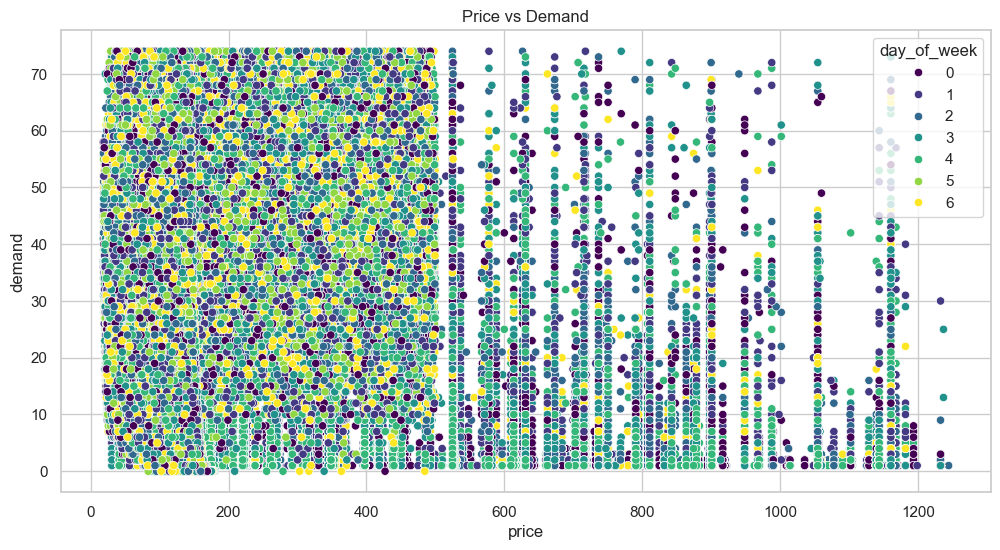

In [8]:
sns.scatterplot(data=df, x='price', y='demand', hue='day_of_week', palette='viridis')
plt.title('Price vs Demand')
plt.show()

# Price Elasticity

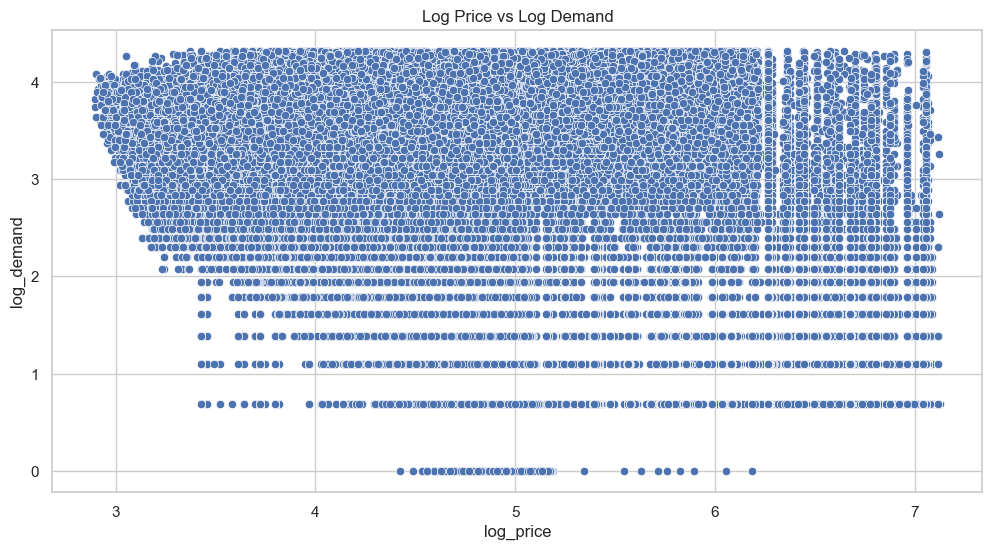

In [9]:
import numpy as np
df["log_price"] = np.log(df["price"])
# Use log1p to safely handle demand = 0
df["log_demand"] = np.log1p(df["demand"])

sns.scatterplot(x="log_price", y="log_demand", data=df)
plt.title("Log Price vs Log Demand")
plt.show()


# Competitor Price Analysis

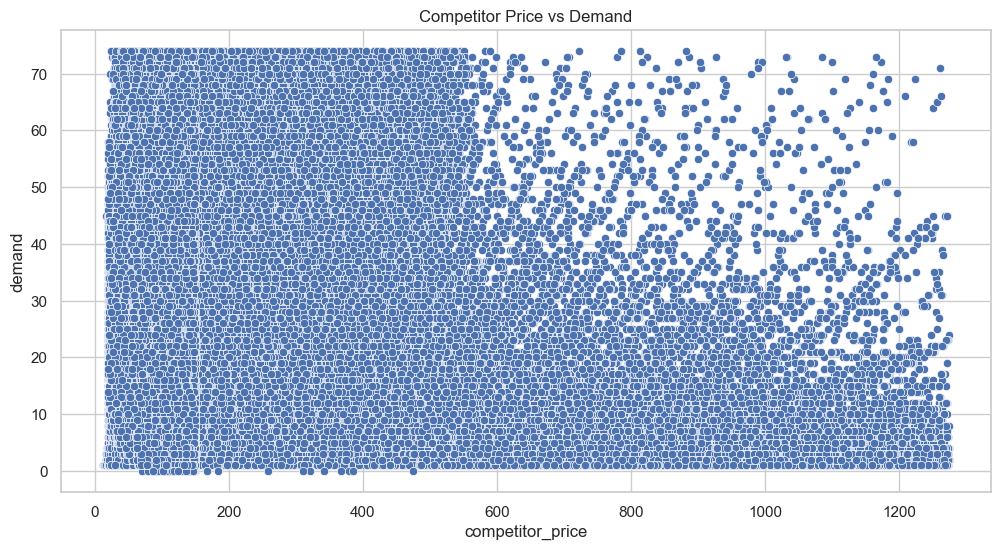

In [10]:
sns.scatterplot(x="competitor_price", y="demand", data=df)
plt.title("Competitor Price vs Demand")
plt.show()

# Inventory Effect

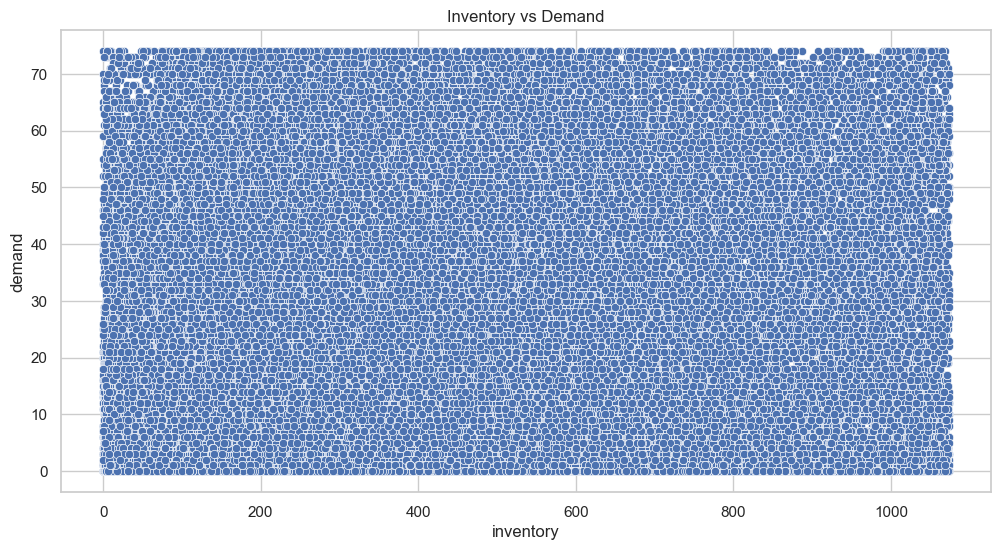

In [11]:
sns.scatterplot(x="inventory", y="demand", data=df)
plt.title("Inventory vs Demand")
plt.show()

# Seasonality Analysis

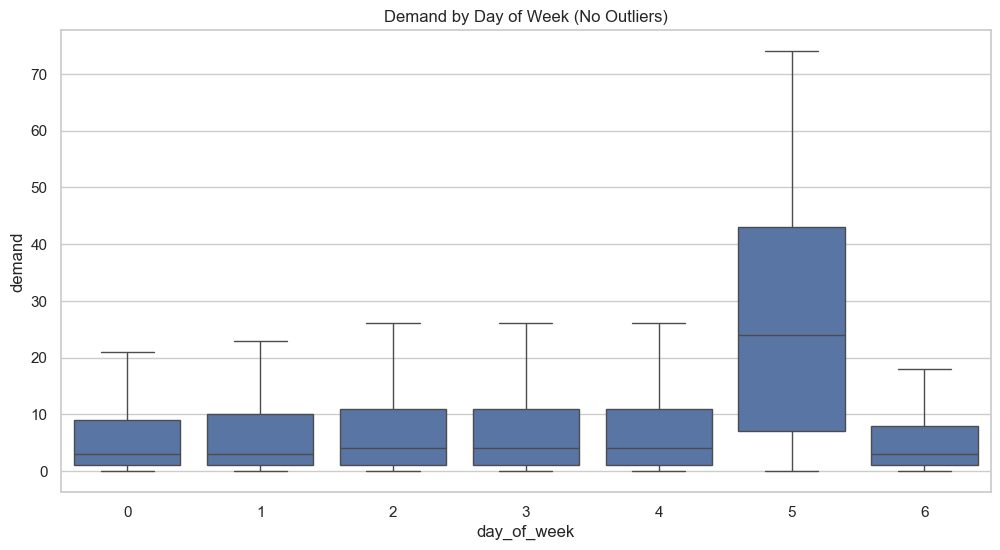

In [12]:
sns.boxplot(x="day_of_week", y="demand", data=df, showfliers=False)
plt.title("Demand by Day of Week (No Outliers)")
plt.show()


## Economic Interpretation



The scatter plot shows a negative relationship between price and demand,
consistent with economic demand theory.

Higher competitor prices appear to increase demand for our product,
suggesting substitution effects.

# Testing Feature Engineering

In [13]:
def create_features(df: pd.DataFrame) -> pd.DataFrame:

    df = df.copy()

    # price difference from competitor
    df["price_gap"] = df["price"] - df["competitor_price"]

    # normalized inventory
    df["inventory_pressure"] = df["inventory"] / df["inventory"].max()

    # weekend indicator
    df["is_weekend"] = df["day_of_week"].isin([5,6]).astype(int)

    return df

In [14]:
import sys
import os

sys.path.append(os.path.abspath(".."))
from src.features.feature_engineering import create_features

df = create_features(df)

df.to_csv("../data/processed/super_model_data_clean.csv", index=False)

# The Price Elasticity Curve (Demand vs. Price Ratio)

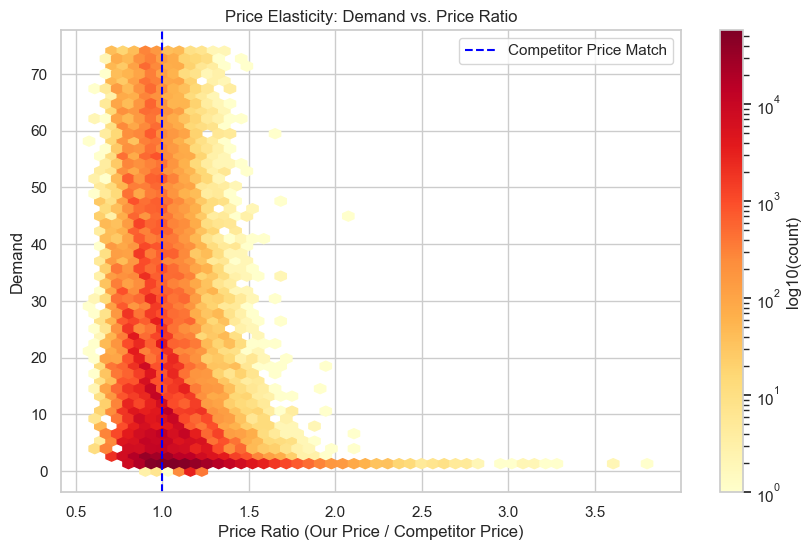

In [15]:
plt.figure(figsize=(10, 6))
# Using a hexbin plot to handle 1.1 million overlapping dots
plt.hexbin(df['price_ratio'], df['demand'], gridsize=50, cmap='YlOrRd', bins='log')
plt.colorbar(label='log10(count)')
plt.axvline(x=1.0, color='blue', linestyle='--', label='Competitor Price Match')
plt.title("Price Elasticity: Demand vs. Price Ratio")
plt.xlabel("Price Ratio (Our Price / Competitor Price)")
plt.ylabel("Demand")
plt.legend()
plt.show()


# The Stockout Effect (Inventory vs. Demand)

 Let's visualize how low inventory restricts potential demand.

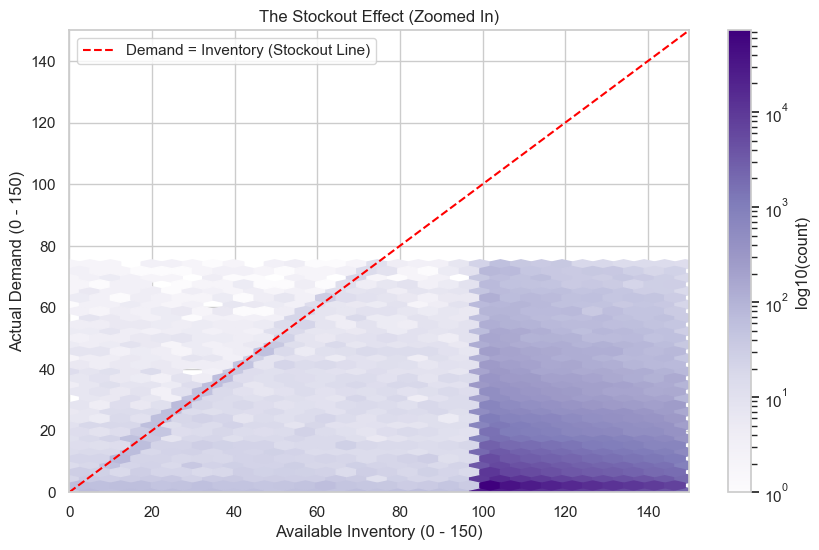

In [16]:
plt.figure(figsize=(10, 6))

# Zoom in on the data by filtering the dataframe directly
zoomed_df = df[(df['inventory'] < 150) & (df['demand'] < 150)]

# Plot the hexbin
plt.hexbin(zoomed_df['inventory'], zoomed_df['demand'], gridsize=30, cmap='Purples', bins='log')
plt.colorbar(label='log10(count)')

# Draw the red stockout line
plt.plot([0, 150], [0, 150], color='red', linestyle='--', label='Demand = Inventory (Stockout Line)')

plt.title("The Stockout Effect (Zoomed In)")
plt.xlabel("Available Inventory (0 - 150)")
plt.ylabel("Actual Demand (0 - 150)")
plt.xlim(0, 150)
plt.ylim(0, 150)
plt.legend()
plt.show()

## A Deep Dive into a Single Product's Timeline

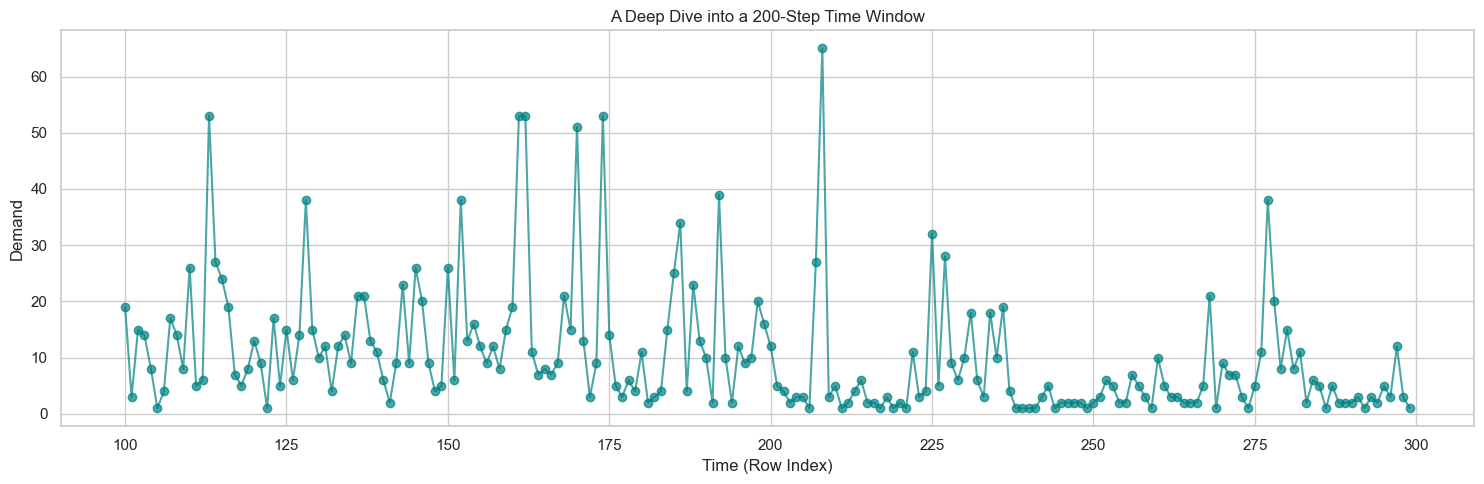

In [17]:
# Select a window of 200 continuous time steps to visualize
time_window = df.iloc[100:300] 

plt.figure(figsize=(15, 5))
# We use the row index as the 'Time' axis
plt.plot(time_window.index, time_window['demand'], marker='o', linestyle='-', alpha=0.7, color='teal')
plt.title("A Deep Dive into a 200-Step Time Window")
plt.xlabel("Time (Row Index)")
plt.ylabel("Demand")
plt.tight_layout()
plt.show()


## Revenue Response to Price Changes

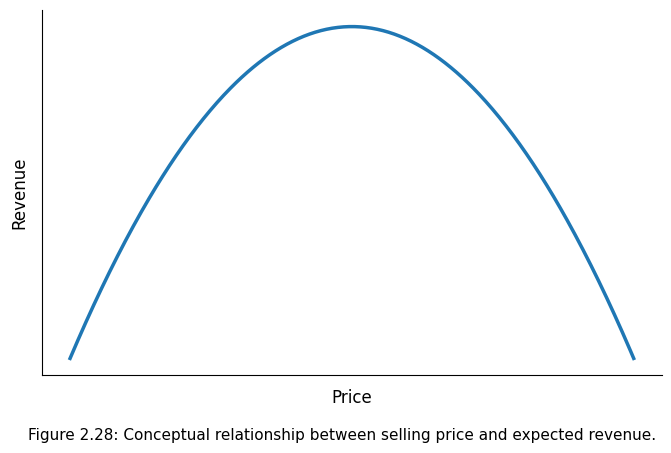

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the relationship
# Let's create a range of prices from 0 to 100
price = np.linspace(0, 100, 500)

# Assume a simple linear demand curve: Demand = 100 - Price
demand = np.maximum(0, 100 - price)

# Calculate expected Revenue (Revenue = Price * Demand)
revenue = price * demand

# 2. Create the plot
plt.figure(figsize=(8, 5))
plt.plot(price, revenue, color='#1f77b4', linewidth=2.5)

# 3. Add titles and labels to match the figure
# plt.title('Figure 2.30 Revenue Response to Price Changes', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Price', fontsize=12, labelpad=10)
plt.ylabel('Revenue', fontsize=12, labelpad=10)

# 4. Clean up the axes for a "conceptual" look (removing numbers/ticks)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks([]) # Hide x-axis numbers
plt.yticks([]) # Hide y-axis numbers

# 5. Add the figure caption at the bottom
plt.figtext(0.5, 0.02, "Figure 2.28: Conceptual relationship between selling price and expected revenue.", 
            wrap=True, horizontalalignment='center', fontsize=11)

# Adjust layout to fit the caption
plt.subplots_adjust(bottom=0.15)
plt.show()


## Price Response Curve

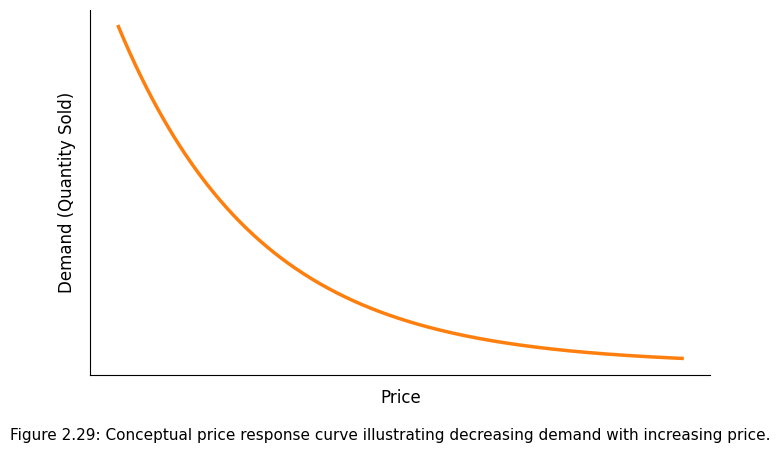

In [5]:
# 1. Define the relationship
# Generate a range of prices from 0 to 100
price = np.linspace(0, 100, 500)

# Create a decreasing demand curve using exponential decay
# (Demand starts at 100 and drops as price increases)
demand = 100 * np.exp(-0.04 * price)

# 2. Create the plot
plt.figure(figsize=(8, 5))
plt.plot(price, demand, color='#ff7f0e', linewidth=2.5)  # Using a nice distinct orange color

# 3. Add titles and labels
plt.xlabel('Price', fontsize=12, labelpad=10)
plt.ylabel('Demand (Quantity Sold)', fontsize=12, labelpad=10)

# 4. Clean up the axes for a "conceptual" presentation (removing numbers/ticks)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks([]) # Hide x-axis numbers
plt.yticks([]) # Hide y-axis numbers

# 5. Add the figure caption at the bottom
plt.figtext(0.5, 0.02, "Figure 2.29: Conceptual price response curve illustrating decreasing demand with increasing price.", 
            wrap=True, horizontalalignment='center', fontsize=11)

# Adjust layout to fit the caption
plt.subplots_adjust(bottom=0.15)
plt.show()

Training RL Agent for 100 epochs...


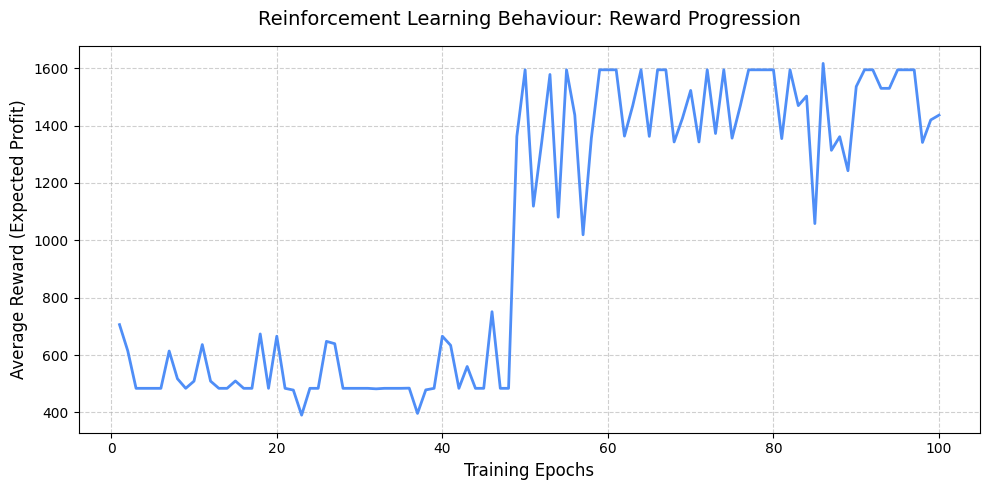

In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt

# Ensure project root is in path so we can import src modules
project_root = str(Path().resolve().parent)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.services.rl_pricing_service import RLPricingService

# 1. Initialize the RL Service
rl_service = RLPricingService()
rl_service.startup()

# 2. Define a simulated market context
competitor_price = 115.0
inventory = 500
day_of_week = 2
unit_cost = 60.0

# 3. Train the agent over multiple epochs and collect average rewards
epochs = 100
reward_history = []

print(f"Training RL Agent for {epochs} epochs...")
for i in range(epochs):
    # Train for 5 episodes per epoch
    result = rl_service.train_on_experience(
        competitor_price=competitor_price,
        inventory=inventory,
        day_of_week=day_of_week,
        unit_cost=unit_cost,
        num_episodes=5,
        save_policy=False  # Keep it False so we don't overwrite your production Q-table
    )
    reward_history.append(result["average_reward"])

# 4. Plot the reward progression (Learning Curve)
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), reward_history, linestyle='-', color='#4f8ef7', linewidth=2)
plt.title('Reinforcement Learning Behaviour: Reward Progression', fontsize=14, pad=15)
plt.xlabel('Training Epochs', fontsize=12)
plt.ylabel('Average Reward (Expected Profit)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Display the graph
plt.show()
